# Decision Tree Implementation

## Overview

In this notebook, I applied **Decision Tree** to predict Big Five personality traits (Extraversion, Agreeableness, Conscientiousness, Neuroticism, Openness) from textual life narrative responses (Q1–Q32).

## What are Decision and Regression Trees?
A **Decision Tree** partitions the feature space by repeatedly asking yes/no questions (splits) about features, creating a tree of decisions. For regression (continuous targets like Big Five scores), it's called a **Regression Tree** — each leaf predicts the **mean** of training samples that fall into that region.

### Splitting criterion
At each node, the tree finds the feature and threshold that minimizes **Mean Squared Error (MSE)** across the two resulting groups.

### Why Decision Trees for personality prediction?
- Highly interpretable — you can visualize exactly what splits are made
- Captures non-linear relationships naturally
- Useful baseline before ensemble methods (Random Forests, Gradient Boosting)
- Feature importance is straightforward to compute

### Key risk: Overfitting
Fully grown trees memorize training data. We control this with `max_depth` and `min_samples_split`.

### Pipeline
```
Narrative text (Q columns)
        ↓
TF-IDF Vectorization
        ↓
TruncatedSVD → 100 dense dimensions
        ↓
DecisionTreeRegressor (one per trait)
        ↓
5-Fold Cross-Validation + Evaluation
```

## 1. Data preprocessing, import required packages

As specified in the random forest module, all narrative columns are combined into a single text string per participant, then apply **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert text into a numeric matrix. 

The key process of supervised learning is for model to learn patterns from training set and evaluate model performance on unseen test set. Thus, data is split into **80% training** and **20% testing**.`random_state=42` ensures reproducibility

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")

# Find repo root automatically
repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

# Text features
q_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Q")]

X_text = df[q_cols].copy()
X_all = X_text.fillna("").agg(" ".join, axis=1)

# Targets
big_five = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Neuroticism",
    "Openness",
]

y = df[big_five].copy()

print("✓ Data preprocessing complete")
print("Repo root:", repo_root)
print("df shape:", df.shape)
print("X_text shape:", X_text.shape)
print("X_all shape:", X_all.shape)
print(y.describe().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

✓ Imports complete
✓ Data preprocessing complete
Repo root: /Users/cindy/cmor438_Spring2026/cmor438_Spring2026
df shape: (500, 138)
X_text shape: (500, 32)
X_all shape: (500,)
       Extraversion  Agreeableness  Conscientiousness  Neuroticism  Openness
count       500.000        500.000            500.000      500.000   500.000
mean          3.177          3.786              3.642        2.879     3.833
std           0.761          0.576              0.710        0.846     0.618
min           1.000          2.000              1.083        1.000     1.750
25%           2.667          3.417              3.167        2.333     3.417
50%           3.167          3.833              3.750        2.917     3.833
75%           3.750          4.167              4.083        3.417     4.250
max           5.000          5.000              5.000        4.917     5.000
Training samples : 400
Test samples     : 100


## 2. Cross-Validation & Tune max_depth with GridSearchCV

**5-fold cross-validation** is applied to give a more reliable estimate for model performance.

`max_depth` is the most important hyperparameter:
- `max_depth=None` → fully grown tree → overfits badly
- `max_depth=3–6` → shallow tree → better generalization

`min_samples_split` is also tuned to further control overfitting.

In [2]:
def cross_validate_model(model, X, y, trait_cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        for j, trait in enumerate(trait_cols):
            y_true = y_te[trait].to_numpy()
            y_pred = pred[:, j]
            fold_results.append({
                "Fold": fold + 1, "Trait": trait,
                "MAE": mean_absolute_error(y_true, y_pred),
                "R2":  r2_score(y_true, y_pred),
                "Pearson_r": np.corrcoef(y_true, y_pred)[0, 1]
            })
    results_df = pd.DataFrame(fold_results)
    summary    = results_df.groupby("Trait").mean(numeric_only=True).round(4)
    return results_df, summary


def plot_cv_summary(summary, title):
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(summary.index, summary["R2"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Mean CV R²")
    ax.set_title(title)
    for bar, val in zip(bars, summary["R2"]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined")

✓ Helper functions defined


In [3]:
gs_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1,2), min_df=5, max_features=100_000)),
    ("svd",   TruncatedSVD(n_components=100, random_state=42)),
    ("tree",  DecisionTreeRegressor(random_state=42))
])

param_grid = {
    "tree__max_depth":         [3, 5, 7, 10, None],
    "tree__min_samples_split": [2, 5, 10]
}

gs = GridSearchCV(gs_pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
gs.fit(X_train, y_train["Extraversion"])

best_depth = gs.best_params_["tree__max_depth"]
best_mss   = gs.best_params_["tree__min_samples_split"]

print(f"Best max_depth        : {best_depth}")
print(f"Best min_samples_split: {best_mss}")
print(f"Best CV R²            : {gs.best_score_:.4f}")

/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/cindy/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:54

Best max_depth        : 3
Best min_samples_split: 5
Best CV R²            : -0.1499


In [4]:
tree_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=5,
        max_features=100_000
    )),
    ("svd",  TruncatedSVD(n_components=100, random_state=42)),
    ("reg",  MultiOutputRegressor(
        DecisionTreeRegressor(
            max_depth=best_depth,
            min_samples_split=best_mss,
            random_state=42
        )
    ))
])

tree_model.fit(X_train, y_train)
pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, pred_tree, multioutput="raw_values")
r2_tree  = [r2_score(y_test.iloc[:, i], pred_tree[:, i]) for i in range(y.shape[1])]

print("Decision/Regression Tree — Test Set Performance")
print("MAE by trait:", dict(zip(big_five, mae_tree.round(4))))
print("R²  by trait:", dict(zip(big_five, [round(r, 4) for r in r2_tree])))

Decision/Regression Tree — Test Set Performance
MAE by trait: {'Extraversion': np.float64(0.6401), 'Agreeableness': np.float64(0.3975), 'Conscientiousness': np.float64(0.6043), 'Neuroticism': np.float64(0.7682), 'Openness': np.float64(0.5455)}
R²  by trait: {'Extraversion': -0.0545, 'Agreeableness': -0.0195, 'Conscientiousness': -0.0376, 'Neuroticism': -0.0809, 'Openness': 0.0325}


Decision Tree — 5-Fold Cross-Validation
---------------------------------------------
                      MAE      R2  Pearson_r
Trait                                       
Agreeableness      0.4761 -0.0958    -0.0138
Conscientiousness  0.5701 -0.0062     0.2035
Extraversion       0.6378 -0.1089    -0.0036
Neuroticism        0.6933 -0.0565     0.1248
Openness           0.5183 -0.1058     0.0436


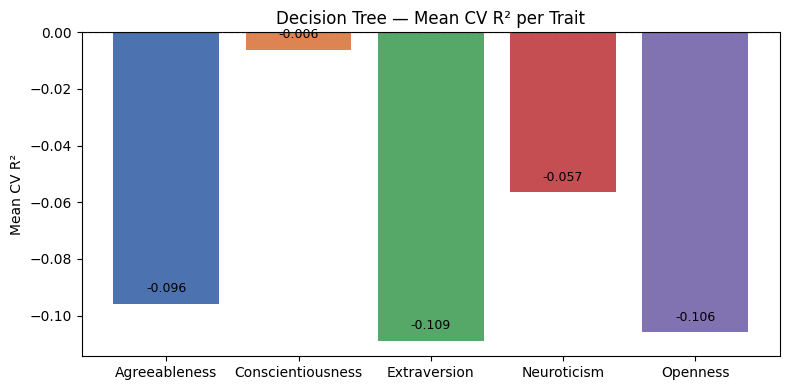

In [5]:
print("Decision Tree — 5-Fold Cross-Validation")
print("-" * 45)

_, summary_tree = cross_validate_model(tree_model, X_all, y, big_five, n_splits=5)

print(summary_tree[["MAE", "R2", "Pearson_r"]])
plot_cv_summary(summary_tree, "Decision Tree — Mean CV R² per Trait")